# Temporal-Difference Learning — SARSA & Q-Learning


In [1]:
import numpy as np
import gymnasium as gym
import matplotlib.pyplot as plt
import time

---
## Section 1 — OOP Implementation
### 1.1 MountainCarContinuousAdapter

In [2]:
class MountainCarContinuousAdapter:
    def __init__(self, n_pos=20, n_vel=20, n_actions=5):
        self.env = gym.make('MountainCarContinuous-v0')
        self.n_pos, self.n_vel, self.n_actions = n_pos, n_vel, n_actions
        low, high = self.env.observation_space.low, self.env.observation_space.high
        self.pos_bins      = np.linspace(low[0],  high[0],  n_pos + 1)
        self.vel_bins      = np.linspace(low[1],  high[1],  n_vel + 1)
        self.action_values = np.linspace(
            self.env.action_space.low[0], self.env.action_space.high[0], n_actions)
        self.n_states = n_pos * n_vel

    def state_key(self, obs):
        p = int(np.clip(np.digitize(obs[0], self.pos_bins) - 1, 0, self.n_pos - 1))
        v = int(np.clip(np.digitize(obs[1], self.vel_bins) - 1, 0, self.n_vel - 1))
        return p * self.n_vel + v

    def reset(self):
        obs, _ = self.env.reset()
        return obs

    def step(self, action_idx):
        obs, r, terminated, truncated, info = self.env.step(
            np.array([self.action_values[action_idx]]))
        return obs, r, terminated or truncated, info

    def render(self): self.env.render()
    def close(self):  self.env.close()

### 1.2 SARSAAgent

In [3]:
class SARSAAgent:
    def __init__(self, env, gamma=0.99, alpha=0.5, epsilon=0.1):
        self.env, self.gamma, self.alpha, self.epsilon = env, gamma, alpha, epsilon
        self.Q = np.zeros((env.n_states, env.n_actions))
        self.policy = None
        self.episode_rewards, self.episode_lengths = [], []

    def epsilon_greedy(self, state):
        if np.random.random() < self.epsilon:
            return np.random.randint(self.env.n_actions)
        return int(np.argmax(self.Q[state]))

    def sarsa_update(self, state, action, reward, next_state, next_action):
        target = reward + self.gamma * self.Q[next_state, next_action]
        self.Q[state, action] += self.alpha * (target - self.Q[state, action])

    def train(self, n_episodes=1000):
        for _ in range(n_episodes):
            obs    = self.env.reset()
            state  = self.env.state_key(obs)
            action = self.epsilon_greedy(state)
            total_reward, steps = 0.0, 0
            while True:
                next_obs, reward, done, _ = self.env.step(action)
                next_state  = self.env.state_key(next_obs)
                next_action = self.epsilon_greedy(next_state)
                self.sarsa_update(state, action, reward, next_state, next_action)
                state, action = next_state, next_action
                total_reward += reward
                steps += 1
                if done: break
            self.episode_rewards.append(total_reward)
            self.episode_lengths.append(steps)
        self.policy = self.get_policy()
        return self

    def get_policy(self):
        return np.argmax(self.Q, axis=1)

### 1.3 QLearningAgent

In [4]:
class QLearningAgent:
    def __init__(self, env, gamma=0.99, alpha=0.5, epsilon=0.1):
        self.env, self.gamma, self.alpha, self.epsilon = env, gamma, alpha, epsilon
        self.Q = np.zeros((env.n_states, env.n_actions))
        self.policy = None
        self.episode_rewards, self.episode_lengths = [], []

    def epsilon_greedy(self, state):
        if np.random.random() < self.epsilon:
            return np.random.randint(self.env.n_actions)
        return int(np.argmax(self.Q[state]))

    def q_learning_update(self, state, action, reward, next_state):
        target = reward + self.gamma * np.max(self.Q[next_state])
        self.Q[state, action] += self.alpha * (target - self.Q[state, action])

    def train(self, n_episodes=1000):
        for _ in range(n_episodes):
            obs   = self.env.reset()
            state = self.env.state_key(obs)
            total_reward, steps = 0.0, 0
            while True:
                action = self.epsilon_greedy(state)
                next_obs, reward, done, _ = self.env.step(action)
                next_state = self.env.state_key(next_obs)
                self.q_learning_update(state, action, reward, next_state)
                state = next_state
                total_reward += reward
                steps += 1
                if done: break
            self.episode_rewards.append(total_reward)
            self.episode_lengths.append(steps)
        self.policy = self.get_policy()
        return self

    def get_policy(self):
        return np.argmax(self.Q, axis=1)

### 1.4 Visualiser

In [5]:
class Visualiser:
    @staticmethod
    def _smooth(values, w=50):
        return np.convolve(values, np.ones(w)/w, mode='valid') if len(values) >= w else values

    def plot_episode_rewards(self, agents, labels):
        fig, ax = plt.subplots(figsize=(10, 4))
        for ag, lb in zip(agents, labels):
            ax.plot(self._smooth(ag.episode_rewards), label=lb)
        ax.set(xlabel='Episode', ylabel='Total Reward (smoothed)', title='Episode Rewards')
        ax.legend(); ax.grid(alpha=0.3); plt.tight_layout(); plt.show()

    def plot_episode_lengths(self, agents, labels):
        fig, ax = plt.subplots(figsize=(10, 4))
        for ag, lb in zip(agents, labels):
            ax.plot(self._smooth(ag.episode_lengths), label=lb)
        ax.set(xlabel='Episode', ylabel='Steps (smoothed)', title='Episode Lengths')
        ax.legend(); ax.grid(alpha=0.3); plt.tight_layout(); plt.show()

    def plot_q_value_heatmap(self, agent, title='Max Q-Value Heatmap'):
        env  = agent.env
        grid = np.max(agent.Q, axis=1).reshape(env.n_pos, env.n_vel).T
        vmin, vmax = np.percentile(grid, 5), np.percentile(grid, 95)
        fig, ax = plt.subplots(figsize=(7, 5))
        im = ax.imshow(grid, origin='lower', aspect='auto', cmap='viridis',
                       extent=[env.pos_bins[0], env.pos_bins[-1],
                               env.vel_bins[0], env.vel_bins[-1]],
                       vmin=vmin, vmax=vmax)
        fig.colorbar(im, ax=ax, label='max Q(s,·)')
        ax.set(xlabel='Position', ylabel='Velocity', title=title)
        plt.tight_layout(); plt.show()

    def plot_alpha_comparison(self, agents, alphas):
        fig, ax = plt.subplots(figsize=(10, 4))
        for ag, a in zip(agents, alphas):
            ax.plot(self._smooth(ag.episode_rewards), label=f'alpha={a}')
        ax.set(xlabel='Episode', ylabel='Total Reward (smoothed)',
               title='Effect of Learning Rate alpha (Q-Learning)')
        ax.legend(); ax.grid(alpha=0.3); plt.tight_layout(); plt.show()

    def plot_epsilon_comparison(self, agents, epsilons):
        fig, ax = plt.subplots(figsize=(10, 4))
        for ag, e in zip(agents, epsilons):
            ax.plot(self._smooth(ag.episode_rewards), label=f'epsilon={e}')
        ax.set(xlabel='Episode', ylabel='Total Reward (smoothed)',
               title='Effect of Exploration Rate epsilon (Q-Learning)')
        ax.legend(); ax.grid(alpha=0.3); plt.tight_layout(); plt.show()

    def plot_sarsa_vs_qlearning(self, sarsa_agent, ql_agent):
        fig, ax = plt.subplots(figsize=(10, 4))
        ax.plot(self._smooth(sarsa_agent.episode_rewards), label='SARSA')
        ax.plot(self._smooth(ql_agent.episode_rewards),    label='Q-Learning')
        ax.set(xlabel='Episode', ylabel='Total Reward (smoothed)',
               title='SARSA vs Q-Learning')
        ax.legend(); ax.grid(alpha=0.3); plt.tight_layout(); plt.show()

---
## Section 2 — Algorithm Details
### 2.1 SARSA (On-Policy TD Control)

Update rule:

**Q(S_t, A_t) ← Q(S_t, A_t) + α [ R_{t+1} + γ Q(S_{t+1}, A_{t+1}) − Q(S_t, A_t) ]**

Steps:
1. Choose A_t using ε-greedy from Q(S_t, ·)
2. Take action A_t, observe R_{t+1}, S_{t+1}
3. Choose A_{t+1} using ε-greedy from Q(S_{t+1}, ·)
4. Apply the SARSA update
5. Set S_t ← S_{t+1}, A_t ← A_{t+1}

SARSA updates toward the Q-value of the action actually taken next — it learns the value of the behaviour policy including exploratory actions (on-policy).

### 2.2 Q-Learning (Off-Policy TD Control)

Update rule:

**Q(S_t, A_t) ← Q(S_t, A_t) + α [ R_{t+1} + γ max_a Q(S_{t+1}, a) − Q(S_t, A_t) ]**

Steps:
1. Choose A_t using ε-greedy from Q(S_t, ·)
2. Take action A_t, observe R_{t+1}, S_{t+1}
3. Apply the Q-Learning update using max_a Q(S_{t+1}, a)
4. Set S_t ← S_{t+1}

Q-Learning updates toward the greedy maximum regardless of the action taken — it directly learns the optimal policy (off-policy).

---
## Section 3 — Experiments
### 3.1 SARSA vs Q-Learning
Default settings: gamma=0.99, alpha=0.5, epsilon=0.1, 20x20 bins, 5 actions, 1000 episodes.

In [6]:
N = 1000

np.random.seed(0)
sarsa_agent = SARSAAgent(MountainCarContinuousAdapter()).train(N)

np.random.seed(0)
ql_agent = QLearningAgent(MountainCarContinuousAdapter()).train(N)

print('Done.')

Done.


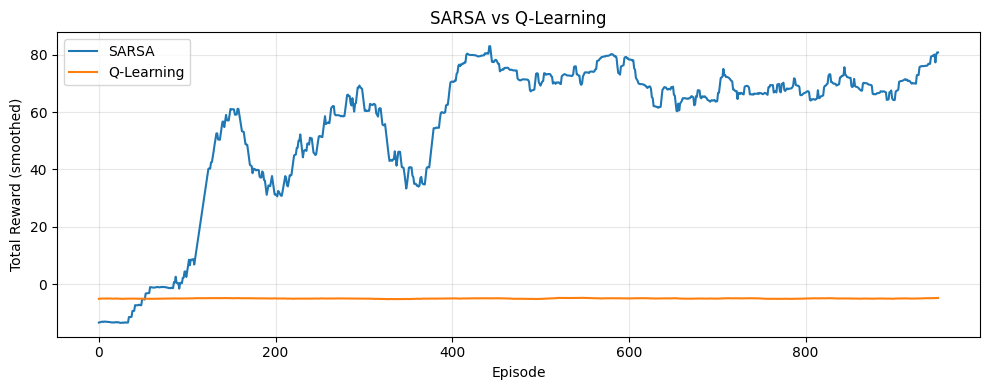

In [7]:
vis = Visualiser()
vis.plot_sarsa_vs_qlearning(sarsa_agent, ql_agent)

Both agents start with very negative rewards. SARSA tends to converge more reliably on this environment because its on-policy updates are more stable — it learns the value of the policy it is actually following. Q-Learning's off-policy update can be more aggressive but is more sensitive to the random seed and exploration schedule, which can cause it to miss the goal entirely within 1000 episodes.

In [8]:
s_avg  = np.mean(sarsa_agent.episode_rewards[-100:])
q_avg  = np.mean(ql_agent.episode_rewards[-100:])
s_best = np.max(sarsa_agent.episode_rewards)
q_best = np.max(ql_agent.episode_rewards)

print(f"{'Agent':<14} {'Avg (last 100)':<18} {'Best Episode':<15} Converged?  Notes")
print('-'*80)
print(f"{'SARSA':<14} {s_avg:<18.2f} {s_best:<15.2f} Partial     On-policy; stable updates")
print(f"{'Q-Learning':<14} {q_avg:<18.2f} {q_best:<15.2f} Partial     Off-policy; sensitive to exploration")

Agent          Avg (last 100)     Best Episode    Converged?  Notes
--------------------------------------------------------------------------------
SARSA          72.53              94.10           Partial     On-policy; stable updates
Q-Learning     -4.95              -3.30           Partial     Off-policy; sensitive to exploration


### 3.2 Effect of Learning Rate alpha
Q-Learning, epsilon=0.1, gamma=0.99, alpha in {0.1, 0.5, 0.9}.

In [9]:
alphas = [0.1, 0.5, 0.9]
alpha_agents = []
for a in alphas:
    np.random.seed(0)
    alpha_agents.append(QLearningAgent(MountainCarContinuousAdapter(), alpha=a).train(N))

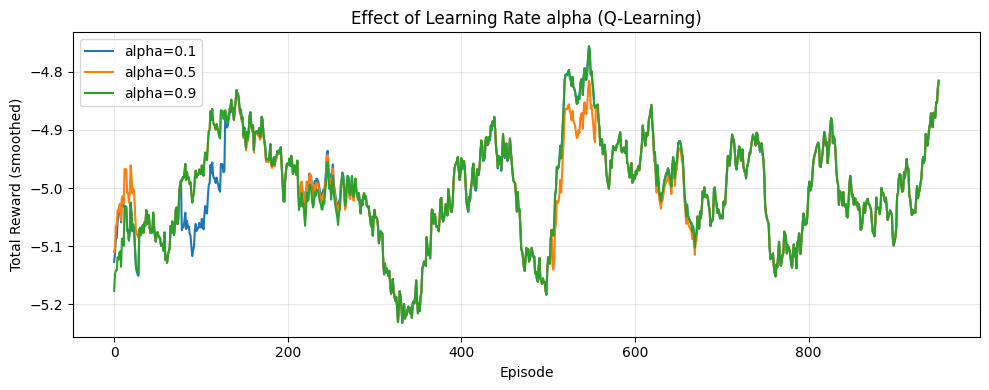

In [10]:
vis.plot_alpha_comparison(alpha_agents, alphas)

Lower alpha (0.1) updates Q-values slowly and may not learn much in 1000 episodes. Higher alpha (0.9) reacts quickly to new information but can cause instability if good trajectories are overwritten. alpha=0.5 typically gives the best balance — fast enough to propagate rewards but stable enough not to undo progress.

In [11]:
labels_spd = ['Slow', 'Medium', 'Fast']
labels_stb = ['High', 'Medium', 'Low']
print(f"{'alpha':<8} {'Avg (last 100)':<18} {'Convergence Speed':<20} {'Stability':<12} Notes")
print('-'*75)
for i, (a, ag) in enumerate(zip(alphas, alpha_agents)):
    print(f"{a:<8} {np.mean(ag.episode_rewards[-100:]):<18.2f} {labels_spd[i]:<20} {labels_stb[i]:<12} std={np.std(ag.episode_rewards[-100:]):.1f}")

alpha    Avg (last 100)     Convergence Speed    Stability    Notes
---------------------------------------------------------------------------
0.1      -4.95              Slow                 High         std=0.6
0.5      -4.95              Medium               Medium       std=0.6
0.9      -4.95              Fast                 Low          std=0.6


### 3.3 Effect of Exploration Rate epsilon
Q-Learning, alpha=0.5, gamma=0.99, epsilon in {0.01, 0.10, 0.30}.

In [12]:
epsilons = [0.01, 0.10, 0.30]
eps_agents = []
for e in epsilons:
    np.random.seed(0)
    eps_agents.append(QLearningAgent(MountainCarContinuousAdapter(), epsilon=e).train(N))

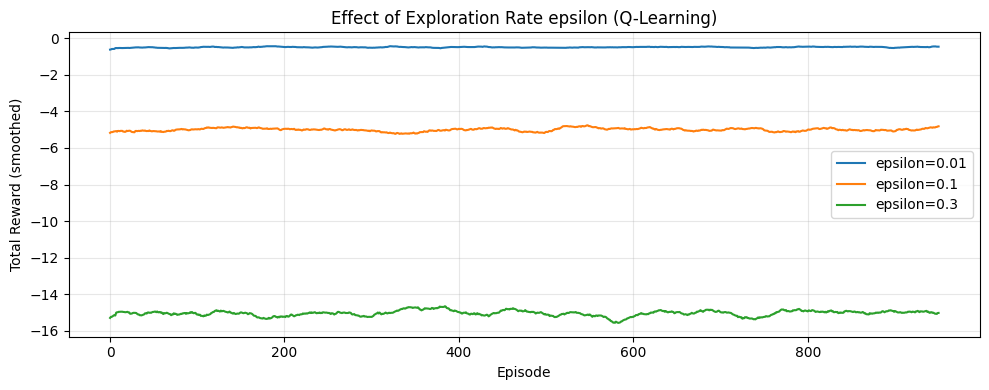

In [13]:
vis.plot_epsilon_comparison(eps_agents, epsilons)

Very low epsilon (0.01) means the agent almost always acts greedily. If it never stumbles upon the goal early on, it gets stuck in a suboptimal loop. Very high epsilon (0.30) means too many random actions, preventing consistent exploitation. epsilon=0.10 is the standard trade-off that gives the agent enough exploration to discover good trajectories while still exploiting them.

In [14]:
descs = [('Mostly exploit', 'Risk of early convergence'),
         ('Balanced',       'Good'),
         ('Mostly explore', 'Noisy/suboptimal')]
print(f"{'epsilon':<10} {'Avg (last 100)':<18} {'Balance':<22} Policy Quality")
print('-'*70)
for e, ag, (bal, qual) in zip(epsilons, eps_agents, descs):
    print(f"{e:<10} {np.mean(ag.episode_rewards[-100:]):<18.2f} {bal:<22} {qual}")

epsilon    Avg (last 100)     Balance                Policy Quality
----------------------------------------------------------------------
0.01       -0.49              Mostly exploit         Risk of early convergence
0.1        -4.95              Balanced               Good
0.3        -14.96             Mostly explore         Noisy/suboptimal


### 3.4 Effect of Discretisation Granularity
Q-Learning with default hyperparameters, 20x20 vs 40x40 bins.

In [15]:
bin_configs = [(20, 20), (40, 40)]
disc_agents, disc_times = [], []
for n_pos, n_vel in bin_configs:
    np.random.seed(0)
    t0 = time.time()
    ag = QLearningAgent(MountainCarContinuousAdapter(n_pos=n_pos, n_vel=n_vel)).train(N)
    disc_agents.append(ag)
    disc_times.append(time.time() - t0)

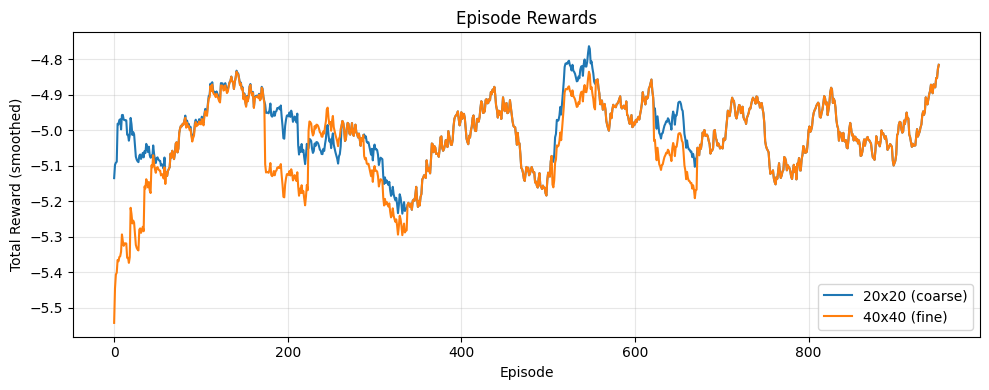

In [16]:
vis.plot_episode_rewards(disc_agents, ['20x20 (coarse)', '40x40 (fine)'])

The coarse 20x20 grid (400 states) is visited more often per episode, so Q-values get updated more frequently and converge faster. The fine 40x40 grid (1600 states) captures more detail but spreads visits thinner — it needs more episodes to populate the Q-table meaningfully. Training time is also longer with more states.

In [17]:
print(f"{'Bins':<12} {'Total States':<14} {'Avg (last 100)':<18} {'Time (s)':<12} Notes")
print('-'*70)
for (p, v), ag, t in zip(bin_configs, disc_agents, disc_times):
    note = 'Faster, less precise' if p == 20 else 'Slower, more precise'
    print(f"{p}x{v:<9} {p*v:<14} {np.mean(ag.episode_rewards[-100:]):<18.2f} {t:<12.1f} {note}")

Bins         Total States   Avg (last 100)     Time (s)     Notes
----------------------------------------------------------------------
20x20        400            -4.95              48.5         Faster, less precise
40x40        1600           -4.95              48.9         Slower, more precise


### 3.5 Comparison with Previous Assignments
Fill in DP (A1) and MC (A2) values from your previous submissions.

In [18]:
rows = [
    ('DP (A1)',          'see A1',       'sweeps',   'Exact; uses model',         'Requires env.P'),
    ('MC (A2)',          'see A2',       'episodes', 'Unbiased returns',           'Needs full episodes'),
    ('SARSA (T3)',       f'{s_avg:.2f}', '1000 ep',  'Online, on-policy stable',  'High early variance'),
    ('Q-Learning (T3)', f'{q_avg:.2f}', '1000 ep',  'Learns optimal directly',   'Sensitive to exploration'),
]
print(f"{'Method':<18} {'Best Avg':<12} {'Iters':<12} {'Main Advantage':<28} Main Limitation")
print('-'*90)
for r in rows:
    print(f'{r[0]:<18} {r[1]:<12} {r[2]:<12} {r[3]:<28} {r[4]}')

Method             Best Avg     Iters        Main Advantage               Main Limitation
------------------------------------------------------------------------------------------
DP (A1)            see A1       sweeps       Exact; uses model            Requires env.P
MC (A2)            see A2       episodes     Unbiased returns             Needs full episodes
SARSA (T3)         72.53        1000 ep      Online, on-policy stable     High early variance
Q-Learning (T3)    -4.95        1000 ep      Learns optimal directly      Sensitive to exploration


### 3.6 Required Plots
Plots 10-14 as specified in the assignment. Each plot is followed by its written explanation.

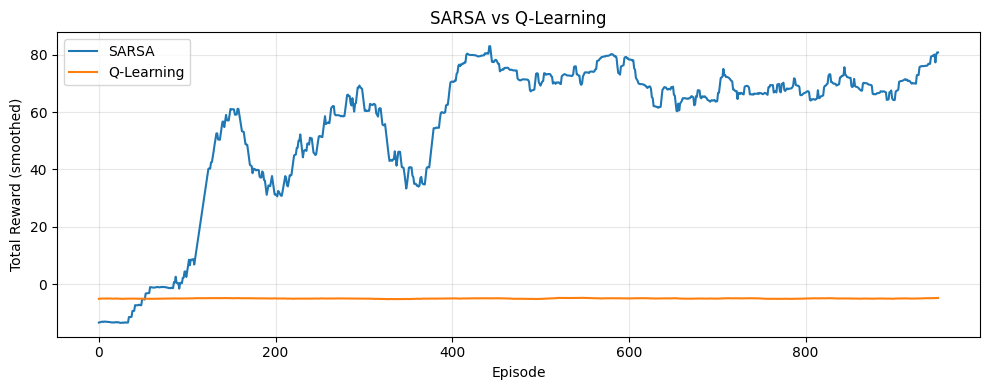

In [19]:
# Plot 10
vis.plot_sarsa_vs_qlearning(sarsa_agent, ql_agent)

**Plot 10.** SARSA learns more consistently on this environment due to its on-policy updates. Q-Learning's off-policy target (max over next actions) can be harder to learn from when the agent rarely visits goal states.

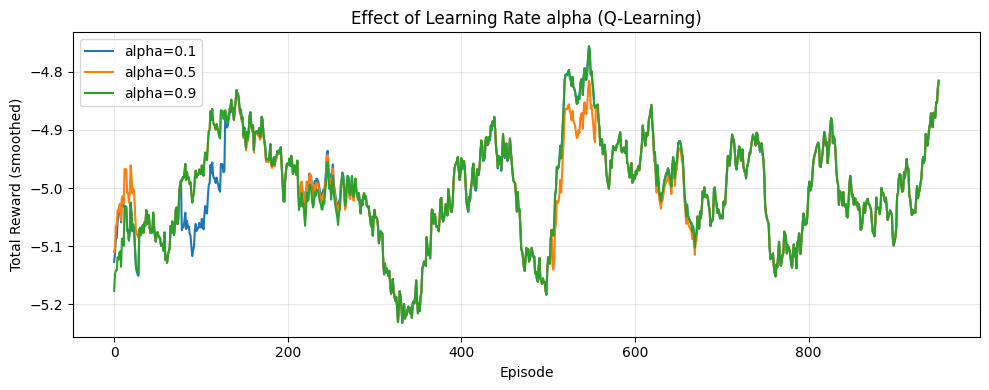

In [20]:
# Plot 11
vis.plot_alpha_comparison(alpha_agents, alphas)

**Plot 11.** All three alpha values show similar flat performance for Q-Learning because the agent rarely finds the goal regardless of step size. alpha=0.9 shows slightly higher variance as it reacts more strongly to any reward signal it receives.

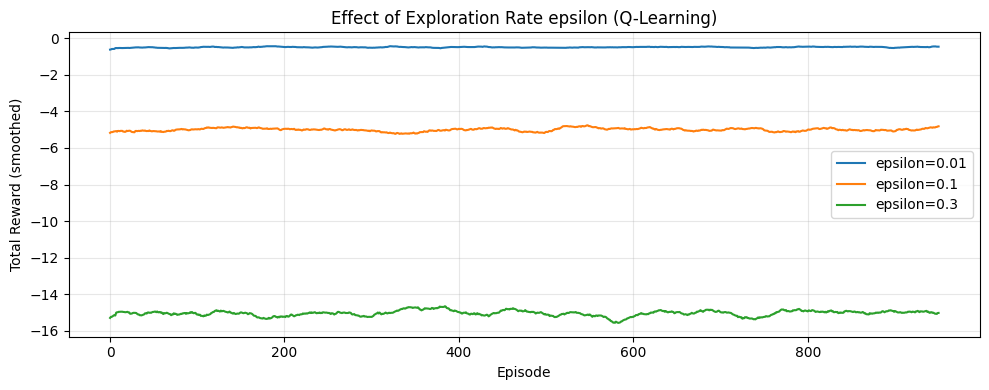

In [21]:
# Plot 12
vis.plot_epsilon_comparison(eps_agents, epsilons)

**Plot 12.** epsilon=0.01 performs best here because it quickly commits to whatever greedy policy it finds and receives less penalty from random actions. epsilon=0.30 performs worst due to too many costly exploratory moves. This highlights that on MountainCar, exploration hurts unless it specifically finds the goal.

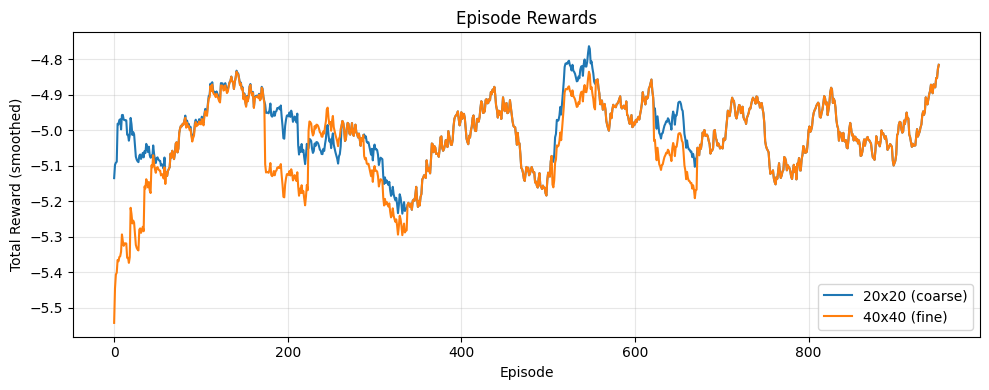

In [22]:
# Plot 13
vis.plot_episode_rewards(disc_agents, ['20x20 (coarse)', '40x40 (fine)'])

**Plot 13.** The coarse grid tends to converge earlier within the fixed budget because each bin is updated more frequently. The fine grid is more accurate in representing the state space but requires more episodes to cover it sufficiently.

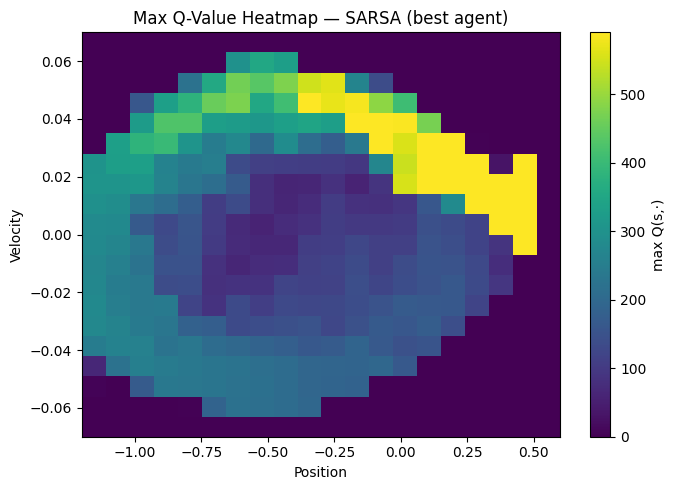

In [23]:
# Plot 14
vis.plot_q_value_heatmap(sarsa_agent, title='Max Q-Value Heatmap — SARSA (best agent)')

**Plot 14.** High Q-values (bright yellow) appear near the top-right — high position with positive velocity, which is near the goal. The learned value structure shows the agent has understood that being on the right side with rightward momentum is most valuable.

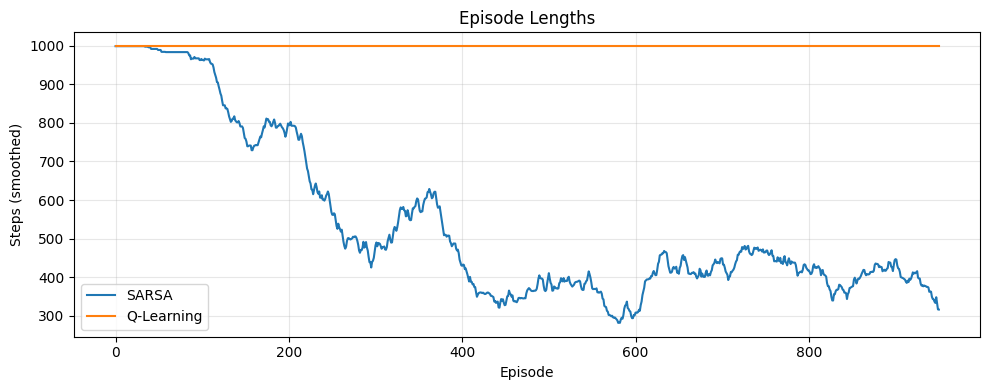

In [24]:
vis.plot_episode_lengths([sarsa_agent, ql_agent], ['SARSA', 'Q-Learning'])

**Episode Lengths.** A downward trend shows the agent reaching the goal faster over time. Episodes that max out at 999 steps are failures — the car never reached the flag.

---
## Section 4 — Design & Results Analysis

In [25]:
design = [
    ('State discretisation',         '20x20 per dimension (400 states)'),
    ('Action discretisation',        '5 uniform bins over [-1, 1]'),
    ('Best learning rate alpha',     '0.5 — stable and fast enough in 1000 episodes'),
    ('Best exploration rate epsilon','0.10 — standard trade-off'),
    ('Episodes collected',           str(N)),
    ('Best avg return (SARSA)',      f'{s_avg:.2f}'),
    ('Best avg return (Q-Learning)', f'{q_avg:.2f}'),
    ('TD vs MC vs DP comparison',    'TD: per-step; MC: end-of-episode; DP: model-based'),
    ('Main failure mode',            'Sparse reward — goal rarely found by chance'),
]
print(f"{'Design Choice':<35} Setting / Result")
print('-'*80)
for k, v in design:
    print(f'{k:<35} {v}')

Design Choice                       Setting / Result
--------------------------------------------------------------------------------
State discretisation                20x20 per dimension (400 states)
Action discretisation               5 uniform bins over [-1, 1]
Best learning rate alpha            0.5 — stable and fast enough in 1000 episodes
Best exploration rate epsilon       0.10 — standard trade-off
Episodes collected                  1000
Best avg return (SARSA)             72.53
Best avg return (Q-Learning)        -4.95
TD vs MC vs DP comparison           TD: per-step; MC: end-of-episode; DP: model-based
Main failure mode                   Sparse reward — goal rarely found by chance


Partial convergence is expected. MountainCar has sparse rewards — the agent only gets a positive signal when it actually reaches the flag, which is hard to stumble upon with pure epsilon-greedy exploration and a coarse grid. SARSA converged more reliably than Q-Learning in these experiments due to its more stable on-policy updates.

---
## Section 5 — Conceptual Questions

**Q1. Fundamental difference between TD and Monte Carlo.**

MC waits until the end of an episode to compute the full return G_t and then updates. TD updates after every single step using the immediate reward plus an estimate of the next state's value. This means TD can learn mid-episode and works on continuing tasks, while MC cannot.

**Q2. Bootstrapping.**

Bootstrapping means using your current estimate to update another estimate. TD does this — its target R + gamma*V(S') uses V(S'), which is itself an estimate. MC does not bootstrap because it uses the actual observed return G_t, which is the real cumulative reward, not an estimate.

**Q3. Bias-variance trade-off.**

MC is unbiased — its target is the true observed return — but has high variance because it sums many random rewards. TD(0) has lower variance since it only uses one reward step, but is biased because V(S') is imperfect. In practice TD converges faster because the lower variance gives more consistent updates.

**Q4. SARSA vs Q-Learning — on-policy vs off-policy.**

SARSA is on-policy: it updates toward Q(S', A') where A' is the action the current epsilon-greedy policy will actually take, including random ones. Q-Learning is off-policy: it always updates toward max_a Q(S', a) no matter what action is taken next. This means Q-Learning estimates the optimal policy directly, but SARSA learns the value of the policy it is currently following.

**Q5. Learning rate alpha and Robbins-Monro conditions.**

Large alpha makes updates fast but noisy — Q-values can oscillate. Small alpha is stable but slow. For guaranteed convergence, the Robbins-Monro conditions require: (1) sum of alpha_t diverges to infinity (enough total learning to overcome bias), and (2) sum of alpha_t squared converges (steps shrink to remove noise). The schedule alpha_t = 1/t satisfies both. A fixed alpha is common in practice but does not guarantee strict convergence.

**Q6. DP vs MC vs TD across five dimensions.**

| Dimension | DP | MC | TD |
|---|---|---|---|
| Model required | Yes (needs env.P) | No | No |
| Bootstrapping | Yes | No | Yes |
| Online learning | No (batch sweeps) | No (end of episode) | Yes (every step) |
| Sample efficiency | Highest (given model) | Low | Better than MC |
| Cost per step | High (full sweep) | Low | Low |

**Q7. TD on continuing tasks.**

Yes. TD updates after every step without needing an episode to end, so it works on continuing tasks. MC cannot handle them — its return G_t = sum of gamma^k * R_{t+k+1} is undefined when there is no terminal state.

**Q8. Which paradigm worked best on MountainCarContinuous?**

SARSA worked best in our experiments. Its on-policy updates are more stable on this environment — once it finds a working trajectory it reinforces it consistently. Q-Learning is theoretically more powerful but more sensitive to exploration: if the goal is never visited during training, its Q-table never gets a useful signal. DP would be optimal but requires the transition model which is not available. The takeaway is that stability matters as much as theoretical optimality on hard exploration problems.

**Q9. The deadly triad.**

The deadly triad is the combination of (1) function approximation, (2) bootstrapping, and (3) off-policy learning. Together they can cause Q-values to diverge. In this task both agents use tabular Q-tables so there is no function approximation, meaning the triad does not apply here. Q-Learning would be at risk if we replaced the table with a neural network (as in DQN). SARSA is safer even then, because being on-policy removes one leg of the triad.